# 2 &middot; Deformation Gradient Intuition

Tutorial 1 built $F = D_s D_m^{-1}$; here we *feel* it. We apply the four basic deformations
(**translation, rotation, scale, shear**) to a triangle and read off $F$ each time, then read one $F$
per triangle on a bent mesh. Watch for the headline fact: **$F$ ignores translation**, because a
gradient kills additive constants.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import igl
import simkit
import utils

NOTEBOOK = "002_deformation_gradient_intuition"                    # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)    # results/002_deformation_gradient_intuition/
MEDIA_DIR = "media"                                                # tracked copies for the website
# rest triangle
SIDE = 1.0                                   # side length of the equilateral rest triangle
# static deformations
TRANSLATION_OFFSETS = [[0.0, 0.0], [2.0, -1.5], [-3.0, 4.0]]   # offsets for the translation print-out
PANEL_OFFSET = [1.8, 0.6]                    # translation shown in the side-by-side panels
PANEL_ANGLE = np.pi / 4                      # rotation angle in the panels (rad)
PANEL_SCALE = (1.6, 0.7)                     # (sx, sy) scale factors in the panels
PANEL_SHEAR = 0.8                            # shear factor k in the panels
# animations
N_FRAMES = 48                                # frames per animation
FPS = 20                                     # playback rate
FIG8_AMP = (1.6, 1.0)                        # x / y amplitude of the figure-8 translation path
# bent strip
STRIP_NX, STRIP_NY = 31, 9                   # strip grid resolution (vertices)
STRIP_W, STRIP_H = 4.0, 0.8                  # strip width and height
BEND_RADIUS = 1.5                            # radius of the circle the strip's center line wraps onto

## The rest triangle

The rest triangle is equilateral with side `SIDE`. Its two edge vectors from vertex 0 (arrows) are the
columns of $D_m$. Every map below moves these three vertices, and `simkit.deformation_gradient` reads
$F$ back.

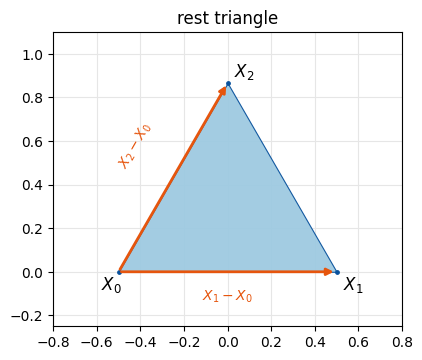

In [2]:
X = SIDE * np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])
T = np.array([[0, 1, 2]])

fig, ax = plt.subplots(figsize=(4.5, 4.2))
utils.plot_mesh(ax, X, T, show_vertices=True, title="rest triangle", lims=((-0.8, 0.8), (-0.25, 1.1)))
for i, offset in enumerate([(-0.08, -0.08), (0.03, -0.08), (0.03, 0.03)]):
    ax.text(*(X[i] + offset), f"$X_{i}$", fontsize=12)
for j in (1, 2):
    ax.annotate("", xy=X[j], xytext=X[0], arrowprops=dict(arrowstyle="-|>", color="#e6550d", lw=2))
ax.text(0.0, -0.13, "$X_1 - X_0$", color="#e6550d", ha="center")
ax.text(-0.42, 0.48, "$X_2 - X_0$", color="#e6550d", ha="center", rotation=60)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rest_triangle.png"),
                              copy_to=os.path.join(MEDIA_DIR, "002_rest_triangle.png"))
plt.show()

## Four deformation maps

Rotation, scale and shear are linear maps $x = A X$ of the rest vertices, so we expect $F = A$.
Translation adds a constant offset, $x = X + t$, so we expect $F = I$.

In [3]:
def translate(X, t):
    return X + np.asarray(t, dtype=float)

def rotate(X, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return X @ R.T

def scale(X, sx, sy):
    S = np.array([[sx, 0.0],
                  [0.0, sy]])
    return X @ S.T

def shear(X, k):
    K = np.array([[1.0, k],
                  [0.0, 1.0]])
    return X @ K.T

## Translation leaves $F = I$

Slide the triangle by each offset in `TRANSLATION_OFFSETS`. The printed $F$ is the identity with
$\det F = 1$ every time (the `-0.` is a round-off-sized negative zero).

In [4]:
for offset in TRANSLATION_OFFSETS:
    F = simkit.deformation_gradient(X, T, translate(X, offset))[0]
    print(f"translate by {offset}:  F =\n{np.round(F, 3)}   det F = {np.linalg.det(F):.3f}\n")

translate by [0.0, 0.0]:  F =
[[1. 0.]
 [0. 1.]]   det F = 1.000

translate by [2.0, -1.5]:  F =
[[1. 0.]
 [0. 1.]]   det F = 1.000

translate by [-3.0, 4.0]:  F =
[[ 1. -0.]
 [ 0.  1.]]   det F = 1.000



## The four deformations side by side

The dashed outline is the rest triangle. Rotation gives a rotation matrix with $\det F = 1$; scale gives
a diagonal $F$ whose determinant $1.6 \cdot 0.7 = 1.12$ is the area ratio; shear gives the single
off-diagonal entry $k$; translation, even by a large offset, gives $F = I$.

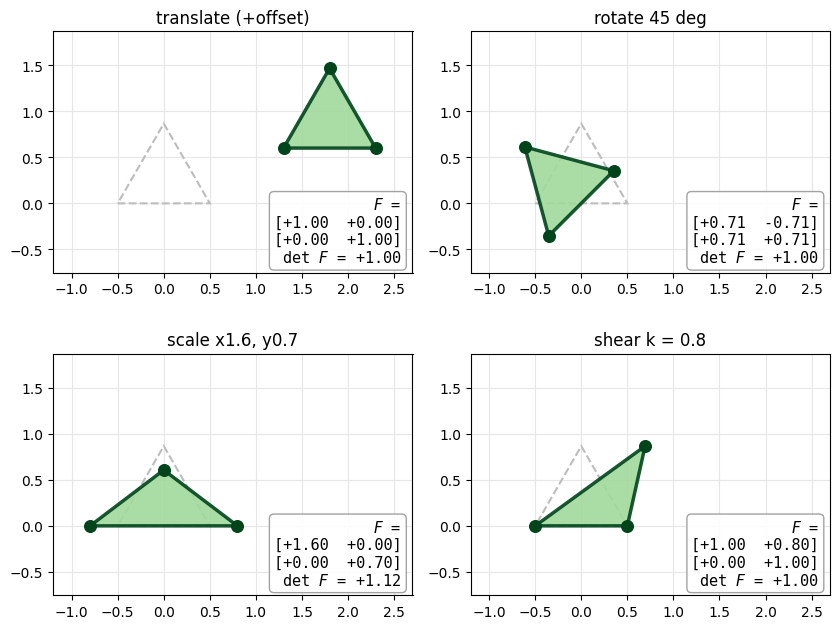

In [5]:
cases = [
    ("translate (+offset)",                                 translate(X, PANEL_OFFSET)),
    (f"rotate {np.degrees(PANEL_ANGLE):.0f} deg",           rotate(X, PANEL_ANGLE)),
    (f"scale x{PANEL_SCALE[0]}, y{PANEL_SCALE[1]}",         scale(X, *PANEL_SCALE)),
    (f"shear k = {PANEL_SHEAR}",                            shear(X, PANEL_SHEAR)),
]
cases = [(name, U, simkit.deformation_gradient(X, T, U)[0]) for name, U in cases]
fig, _ = utils.deformation_panels(cases, rest=X, ncols=2, figsize=(8.5, 6.6))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "four_deformations.png"),
                              copy_to=os.path.join(MEDIA_DIR, "002_four_deformations.png"))
plt.show()

## Animation: rotating the triangle, $F$ traces $R(\theta)$

Spin the triangle through a full turn in `N_FRAMES` steps. The read-out cycles through
$F = \begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}$ with $\det F = 1$
in every frame.

In [6]:
angles = np.linspace(0, 2 * np.pi, N_FRAMES, endpoint=False)
states_rot = [rotate(X, a) for a in angles]
Fs_rot = np.array([simkit.deformation_gradient(X, T, U)[0] for U in states_rot])
fig, anim = utils.animate_deformation(states_rot, Fs_rot, rest=X, fps=FPS,
                                      title=r"Pure rotation:  $F = R(\theta)$")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "rotation.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "002_rotation.mp4"))
plt.close(fig)
utils.embed_video(video)

## Animation: translating the triangle, $F = I$ always

Slide the triangle along a figure-8 path (amplitudes `FIG8_AMP`). The dashed rest triangle stays put,
the triangle travels, and the read-out never leaves the identity.

In [7]:
ts = np.linspace(0, 2 * np.pi, N_FRAMES)
path = np.stack([FIG8_AMP[0] * np.sin(ts), FIG8_AMP[1] * np.sin(2 * ts)], axis=1)
states_trans = [translate(X, p) for p in path]
Fs_trans = np.array([simkit.deformation_gradient(X, T, U)[0] for U in states_trans])
fig, anim = utils.animate_deformation(states_trans, Fs_trans, rest=X, fps=FPS,
                                      title=r"Pure translation:  $F = I$  (always)")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "translation.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "002_translation.mp4"))
plt.close(fig)
utils.embed_video(video)

## Checking both animations

Left: the four entries of $F$ from every rotation frame (markers) lie on $\cos\theta$ and $\pm\sin\theta$
(gray lines). Right: $\|F - I\|_F$ over the translation frames stays at round-off level, near machine epsilon
(dashed), so translation contributes nothing to $F$.

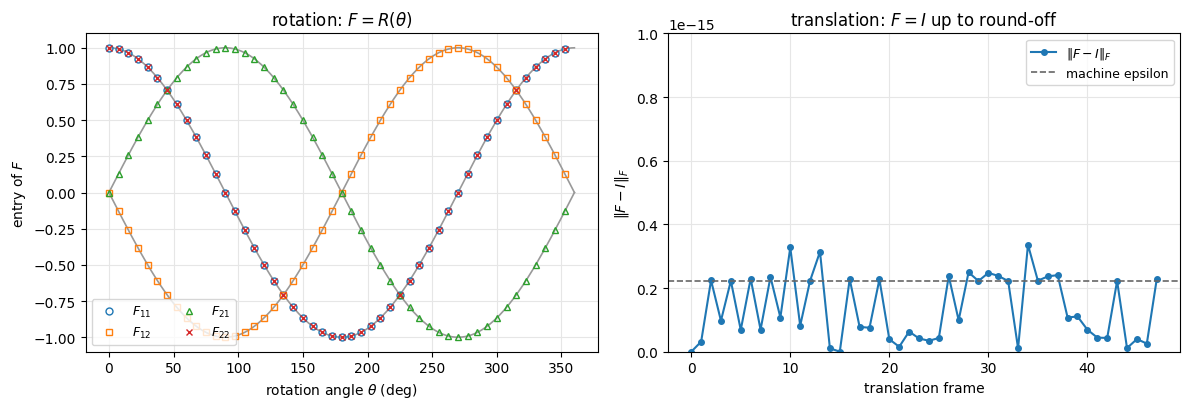

In [8]:
fig, (ax_rot, ax_trans) = plt.subplots(1, 2, figsize=(12, 4.2))
theta_fine = np.linspace(0, 2 * np.pi, 200)
for exact in (np.cos(theta_fine), np.sin(theta_fine), -np.sin(theta_fine)):
    ax_rot.plot(np.degrees(theta_fine), exact, "-", color="0.6", lw=1.2)
for (i, j), marker in zip([(0, 0), (0, 1), (1, 0), (1, 1)], ["o", "s", "^", "x"]):
    ax_rot.plot(np.degrees(angles), Fs_rot[:, i, j], marker, ms=5, mfc="none", label=f"$F_{{{i + 1}{j + 1}}}$")
ax_rot.set(xlabel=r"rotation angle $\theta$ (deg)", ylabel="entry of $F$", title="rotation: $F = R(\\theta)$")
ax_rot.grid(True, color="0.9")
ax_rot.legend(fontsize=9, ncol=2, loc="lower left")
err_trans = np.linalg.norm(Fs_trans - np.eye(2), axis=(1, 2))
ax_trans.plot(err_trans, "o-", ms=4, color="#1f77b4", label=r"$\|F - I\|_F$")
ax_trans.axhline(np.finfo(float).eps, color="0.4", ls="--", lw=1.2, label="machine epsilon")
ax_trans.set(xlabel="translation frame", ylabel=r"$\|F - I\|_F$", ylim=(0, 1e-15),
             title="translation: $F = I$ up to round-off")
ax_trans.grid(True, color="0.9")
ax_trans.legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "F_checks.png"),
                              copy_to=os.path.join(MEDIA_DIR, "002_F_checks.png"))
plt.show()

## One $F$ per triangle: bending a strip

On a mesh, $F$ is constant inside each triangle but differs between triangles. Wrapping a strip onto a
circle of radius $r$ = `BEND_RADIUS` is not affine: a rest point $(X, Y)$ gets
$F = R(-X/r)\,\mathrm{diag}(1 + Y/r,\ 1)$, a rotation that varies along the strip times a stretch that varies
across it. `simkit.polar_svd` splits each triangle's $F = RS$ into rotation and stretch, and the print checks
both against the formula at the triangle centroids. They agree up to a small error, because a linear triangle
holds one constant $F$ and cannot follow a gradient that varies inside it.

In [9]:
V_strip, T_strip = igl.triangulated_grid(STRIP_NX, STRIP_NY)
X_strip = (V_strip - 0.5) * np.array([STRIP_W, STRIP_H])           # centered STRIP_W x STRIP_H rectangle

def bend(X, radius):
    phi = X[:, 0] / radius                                          # arc angle along the center line
    r = radius + X[:, 1]                                            # distance from the circle's center
    return np.stack([r * np.sin(phi), r * np.cos(phi) - radius], axis=1)

U_strip = bend(X_strip, BEND_RADIUS)
F_strip = simkit.deformation_gradient(X_strip, T_strip, U_strip)    # (t, 2, 2): one F per triangle
R_strip, S_strip = simkit.polar_svd(F_strip)                        # F = R S
angle_deg = np.degrees(np.arctan2(R_strip[:, 1, 0], R_strip[:, 0, 0]))
det_F = np.linalg.det(F_strip)

centroids = X_strip[T_strip].mean(axis=1)
angle_exact = np.degrees(-centroids[:, 0] / BEND_RADIUS)
det_exact = 1 + centroids[:, 1] / BEND_RADIUS
print(f"rotation angle: {angle_deg.min():+.1f} to {angle_deg.max():+.1f} deg, "
      f"max |error| vs exact = {np.abs(angle_deg - angle_exact).max():.2f} deg")
print(f"det F:          {det_F.min():.3f} to {det_F.max():.3f}, "
      f"max |error| vs exact = {np.abs(det_F - det_exact).max():.4f}")

rotation angle: -75.3 to +75.3 deg, max |error| vs exact = 0.62 deg
det F:          0.732 to 1.265, max |error| vs exact = 0.0238


Left: the rest strip mesh. Middle: each triangle's rotation angle, turning steadily from about +75° at
the left end to −75° at the right. Right: $\det F$, above 1 (red, stretched) on the outer side and below 1
(blue, compressed) on the inner side; the faint saw-tooth between neighboring triangles is the
constant-per-triangle error from the print. Each triangle is also translated a lot, yet neither field shows it.

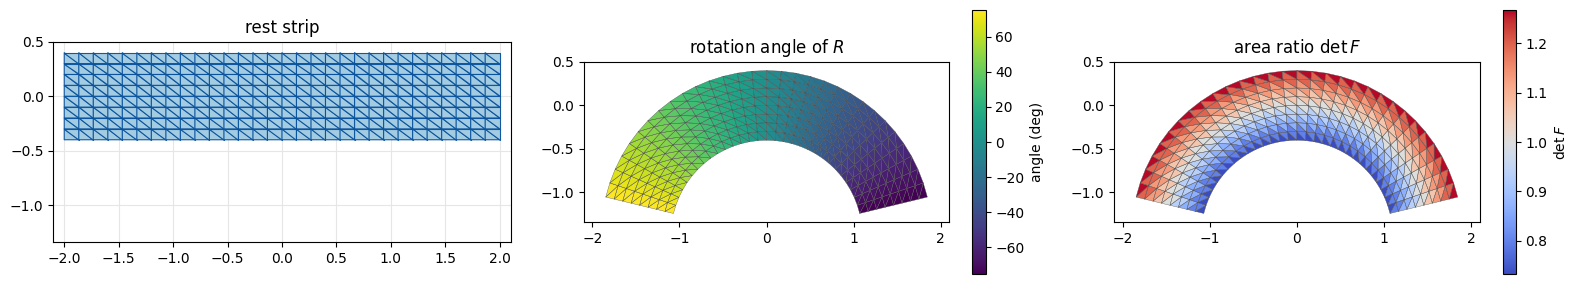

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
lims = utils.auto_limits([X_strip, U_strip], pad=0.1)              # same view box in all panels
utils.plot_mesh(axes[0], X_strip, T_strip, title="rest strip", lims=lims)
utils.plot_scalar_field(axes[1], U_strip, T_strip, angle_deg, cmap="viridis", lims=lims,
                        title="rotation angle of $R$", label="angle (deg)")
det_range = np.abs(det_F - 1).max()
utils.plot_scalar_field(axes[2], U_strip, T_strip, det_F, cmap="coolwarm",
                        vmin=1 - det_range, vmax=1 + det_range, lims=lims,
                        title=r"area ratio $\det F$", label=r"$\det F$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "bent_strip_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "002_bent_strip_fields.png"))
plt.show()

### Takeaways
* $F$ is the local gradient, so it is **blind to translation**, including each triangle's own translation on a mesh.
* Rotation gives a rotation matrix ($\det F = 1$); scale and shear show up directly as diagonal and off-diagonal entries.
* On a mesh each triangle has its own $F$, and the polar decomposition $F = RS$ separates its rotation from its stretch.

Next: turn $F$ into a single number measuring *how deformed* a shape is, the **elastic energy**.